In [13]:
!pip install -q transformers>=4.38.0 scikit-learn pandas matplotlib seaborn

In [ ]:
import re, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"

print(f"Device  : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM    : {vram:.1f} GB")
    print(f"fp16 AMP: {'enabled' if USE_AMP else 'disabled'}")

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
fp16 AMP: enabled


## 2 · Central Config

All hyperparameters live here. Change ONLY this cell to experiment.

Model choice:
- roberta-large — 355M params, best accuracy, needs ~14 GB VRAM with fp16 + batch 8


In [ ]:
DATA_PATH  = "/content/drive/MyDrive/specality_classification/mtsamples.csv"
SAVE_DIR   = "/content/drive/MyDrive/specality_classification/roberta_best"

MODEL_NAME = "roberta-large"

EPOCHS      = 12
BATCH_SIZE  = 8           # roberta-large on T4 fp16; saving some VRAM for optimizer states and gradients
ACCUM_STEPS = 4           # effective batch=8×4=32
MAX_LEN     = 512
PATIENCE    = 4

LR_HEAD     = 2e-5
LLRD_FACTOR = 0.9         # each layer LR=previous × 0.9
WEIGHT_DECAY= 0.01
WARMUP_RATIO= 0.06

LABEL_SMOOTH= 0.05
GRAD_CLIP   = 1.0

MIN_SAMPLES = 20

# ══════════════════════════════════════════════════════════
os.makedirs(SAVE_DIR, exist_ok=True)
print("Config loaded ")
print(f"  Model      : {MODEL_NAME}")
print(f"  Batch size : {BATCH_SIZE}  ×  accum {ACCUM_STEPS}  =  effective {BATCH_SIZE*ACCUM_STEPS}")
print(f"  Max epochs : {EPOCHS}  (early stop patience={PATIENCE})")

Config loaded 
  Model      : roberta-large
  Batch size : 8  ×  accum 4  =  effective 32
  Max epochs : 12  (early stop patience=4)


## 3 · Data Loading & Preprocessing

Why fuse transcription + description?
RoBERTa sees both fields as one sequence, giving richer signal. Your teammate's
BioBERT only sees transcription, so both models complement each other.

Medical text cleaner:
Removes dates, MRN numbers, long digit strings, and non-ASCII punctuation.
For RoBERTa's BPE tokeniser, "01/15/2024" tokenises into ~6 useless tokens.
Cleaning these frees token budget for actual clinical terms.

In [ ]:
def clean(text: str) -> str:
    text = str(text)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " ", text)
    text = re.sub(r"\bMRN?[:\s#]*\d+\b", " ", text, flags=re.I)
    text = re.sub(r"\b\d{5,}\b", " ", text)
    text = re.sub(r"[^\w\s.,;:!?()-]", " ", text)
    text = re.sub(r"[ \t]+", " ", text).strip()
    return text # basic cleaning: remove dates, MRNs, long numbers, special chars; keep punctuation for better RoBERTa tokenization

df = pd.read_csv(DATA_PATH)
df.drop(columns=[c for c in df.columns if "Unnamed" in c], inplace=True)
df["medical_specialty"] = df["medical_specialty"].str.strip()

counts = df["medical_specialty"].value_counts()
df["label"] = df["medical_specialty"].apply(
    lambda x: x if counts[x] >= MIN_SAMPLES else "Other"
)

df["text"] = (
    df["transcription"].fillna("") + " " + df["description"].fillna("")
).apply(clean)

df = df[df["text"].str.len() > 30].reset_index(drop=True)# filter out very short texts

print(f"Rows    : {len(df)}")
print(f"Classes : {df['label'].nunique()}")
print()
print(df["label"].value_counts().to_string())

Rows    : 4987
Classes : 30

label
Surgery                          1098
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  228
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           157
Other                             125
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Dentistry      

In [ ]:
le          = LabelEncoder()# encode string labels to integers
y           = le.fit_transform(df["label"].values)
X           = df["text"].values
NUM_CLASSES = len(le.classes_)
id2label    = {int(i): c for i, c in enumerate(le.classes_)}
label2id    = {c: int(i) for i, c in enumerate(le.classes_)}

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED 
)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print(f"Train : {len(X_tr)}  |  Val : {len(X_val)}  |  Test : {len(X_te)}")
print(f"Classes: {NUM_CLASSES}")

Train : 3490  |  Val : 748  |  Test : 749
Classes: 30


In [ ]:
## 4 · Tokenisation & DataLoaders
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
print(f"Tokeniser loaded: {MODEL_NAME}")

class MedDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(
            list(texts),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long) # convert labels to tensor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids"      : self.enc["input_ids"][idx],
            "attention_mask" : self.enc["attention_mask"][idx],
            "labels"         : self.labels[idx],
        }

train_ds = MedDataset(X_tr,  y_tr)
val_ds   = MedDataset(X_val, y_val)
test_ds  = MedDataset(X_te,  y_te)
print(f"Sizes — train:{len(train_ds)}  val:{len(val_ds)}  test:{len(test_ds)}")

Tokeniser loaded: roberta-large
Sizes — train:3490  val:748  test:749


In [ ]:
train_counts   = np.bincount(y_tr)
sample_weights = 1.0 / train_counts[y_tr] # inverse frequency weighting: rarer classes get higher weights, more likely to be sampled in each batch
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(y_tr),
    replacement=True,
)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Batches — train:{len(train_dl)}  val:{len(val_dl)}  test:{len(test_dl)}")

Batches — train:437  val:94  test:94


## 5 · Model + Layer-wise LR Decay (LLRD)

Why LLRD?
Standard fine-tuning applies the same learning rate to every layer.
Earlier transformer layers encode general language; later layers encode
task-specific patterns. LLRD assigns:

  Classifier head       →  LR_HEAD (2e-5)        — learns fastest
  Last encoder layer    →  LR_HEAD × 0.9 (1.8e-5)
  Second-to-last        →  LR_HEAD × 0.9² (1.62e-5)
  ...
  Embedding layer       →  smallest LR

Prevents catastrophic forgetting in early layers while allowing
aggressive adaptation in upper layers — worth +1–2 F1 consistently.

In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)# load pre-trained RoBERTa with a new classification head, set dropout to 0.1
model.to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_p:,}")
print(f"Trainable params : {trainable_p:,}")# most are trainable since we're fine-tuning the whole model

def get_llrd_params(model, lr_head, decay):
    """
    Returns optimizer param_groups with per-layer learning rates.
    Each encoder layer gets LR = lr_head × decay^(num_layers - layer_idx).
    """
    num_layers = model.config.num_hidden_layers   # 24 for large, 12 for base
    param_groups = []

    param_groups.append({
        "params": list(model.classifier.parameters()),
        "lr"    : lr_head,
    })

    # Encoder layers decaying LR top to bottom
    for layer_idx in range(num_layers - 1, -1, -1):
        layer_lr = lr_head * (decay ** (num_layers - 1 - layer_idx))
        param_groups.append({
            "params": list(model.roberta.encoder.layer[layer_idx].parameters()),
            "lr"    : layer_lr,
        })

    # Embeddings — lowest LR
    embed_lr = lr_head * (decay ** num_layers)
    param_groups.append({
        "params": list(model.roberta.embeddings.parameters()),
        "lr"    : embed_lr,
    })

    return param_groups

param_groups = get_llrd_params(model, LR_HEAD, LLRD_FACTOR)# create param groups with layer-wise LRs for AdamW optimizer
optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

total_steps  = (len(train_dl) // ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
scaler  = GradScaler(enabled=USE_AMP)# for mixed precision training (fp16) if using CUDA

print(f"\nOptimiser   : AdamW with LLRD ({len(param_groups)} param groups)")
print(f"Scheduler   : cosine warmup")
print(f"Total steps : {total_steps}  |  Warmup : {warmup_steps}")
print(f"fp16 AMP    : {'ON' if USE_AMP else 'OFF'}")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params     : 355,390,494
Trainable params : 355,390,494

Optimiser   : AdamW with LLRD (26 param groups)
Scheduler   : cosine warmup
Total steps : 1308  |  Warmup : 78
fp16 AMP    : ON


## 6 · Training Loop

fp16 AMP (Automatic Mixed Precision):
PyTorch's autocast runs the forward pass in float16, reducing VRAM ~40%
and speeding up training ~1.5–2× on T4/A100.
GradScaler prevents fp16 underflow during the backward pass.
This is free accuracy same math, more epochs in same wall-clock time.

Checkpoint format:
The .pt file saves everything needed for inference:
model_state, label2id, id2label, num_classes, model_name, max_len

In [21]:
CKPT_PATH = os.path.join(SAVE_DIR, "roberta_best.pt")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, labels_all = 0.0, [], []

    for step, batch in enumerate(loader, 1):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)

        with autocast(enabled=USE_AMP):
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss   = loss_fn(logits, labs) / ACCUM_STEPS

        if train:
            scaler.scale(loss).backward()
            if step % ACCUM_STEPS == 0 or step == len(loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

        total_loss += loss.item() * ACCUM_STEPS
        preds.extend(logits.argmax(-1).cpu().numpy())
        labels_all.extend(labs.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    f1  = f1_score(labels_all, preds, average="macro", zero_division=0)
    return total_loss / len(loader), acc, f1


best_val_f1 = 0.0
no_improve  = 0
history     = []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_dl, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_dl,   train=False)

    history.append(dict(epoch=epoch,
                        tr_loss=tr_loss, tr_acc=tr_acc, tr_f1=tr_f1,
                        vl_loss=vl_loss, vl_acc=vl_acc, vl_f1=vl_f1))

    marker = ""
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        no_improve  = 0
        torch.save({
            "model_state": model.state_dict(),
            "label2id"   : label2id,
            "id2label"   : id2label,
            "num_classes": NUM_CLASSES,
            "model_name" : MODEL_NAME,
            "max_len"    : MAX_LEN,
        }, CKPT_PATH)
        marker = "  ✓ saved"
    else:
        no_improve += 1
        marker = f"  (no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  F1={tr_f1:.4f} | "
          f"Val    loss={vl_loss:.4f}  acc={vl_acc:.4f}  F1={vl_f1:.4f}"
          + marker)

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping — best val F1 = {best_val_f1:.4f}")
        break

print(f"\nDone. Best val Macro-F1 = {best_val_f1:.4f}")
print(f"Checkpoint saved to: {CKPT_PATH}")

Epoch  1/12 | Train  loss=3.3993  acc=0.0479  F1=0.0370 | Val    loss=3.2480  acc=0.1297  F1=0.0149  ✓ saved
Epoch  2/12 | Train  loss=3.1703  acc=0.1321  F1=0.1099 | Val    loss=3.0639  acc=0.1551  F1=0.0565  ✓ saved
Epoch  3/12 | Train  loss=2.7807  acc=0.2748  F1=0.2373 | Val    loss=2.9503  acc=0.1430  F1=0.1348  ✓ saved
Epoch  4/12 | Train  loss=2.4375  acc=0.3748  F1=0.3308 | Val    loss=2.7827  acc=0.1725  F1=0.1470  ✓ saved
Epoch  5/12 | Train  loss=2.1870  acc=0.4370  F1=0.3957 | Val    loss=2.8418  acc=0.1591  F1=0.1439  (no improve 1/4)
Epoch  6/12 | Train  loss=2.0328  acc=0.4928  F1=0.4505 | Val    loss=2.7469  acc=0.1925  F1=0.1891  ✓ saved
Epoch  7/12 | Train  loss=1.8993  acc=0.5221  F1=0.4793 | Val    loss=2.7788  acc=0.1751  F1=0.1754  (no improve 1/4)
Epoch  8/12 | Train  loss=1.7780  acc=0.5645  F1=0.5268 | Val    loss=2.7142  acc=0.2032  F1=0.1971  ✓ saved
Epoch  9/12 | Train  loss=1.7114  acc=0.5819  F1=0.5480 | Val    loss=2.8049  acc=0.1885  F1=0.2021  ✓ saved
E

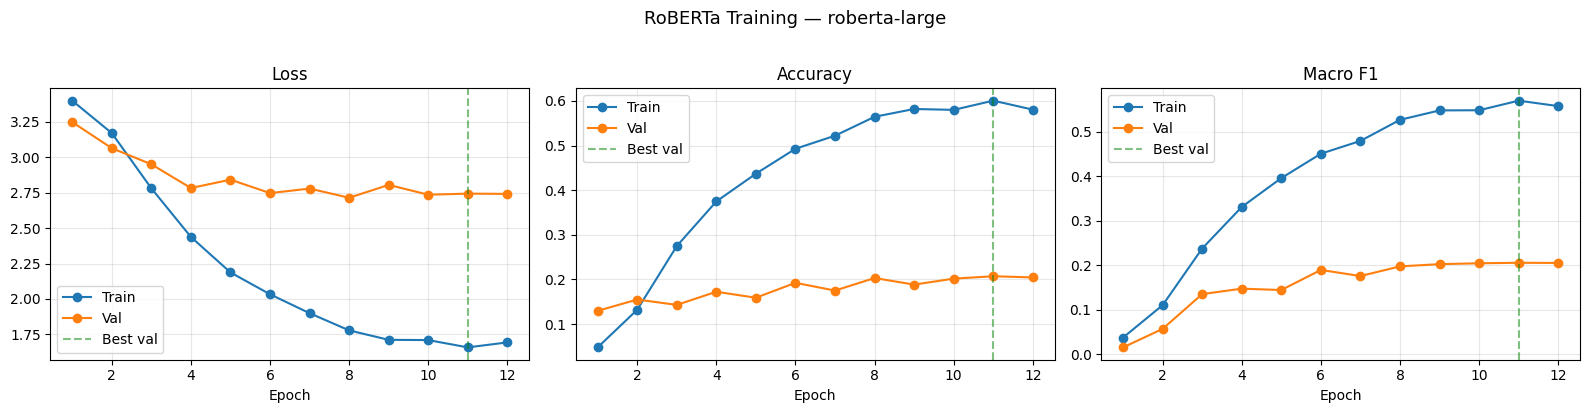

In [24]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (tr_col, vl_col), title in zip(
    axes,
    [("tr_loss","vl_loss"), ("tr_acc","vl_acc"), ("tr_f1","vl_f1")],
    ["Loss", "Accuracy", "Macro F1"],
):
    ax.plot(hist["epoch"], hist[tr_col], marker="o", label="Train")
    ax.plot(hist["epoch"], hist[vl_col], marker="o", label="Val")
    ax.axvline(hist.loc[hist["vl_f1"].idxmax(), "epoch"],
               color="green", linestyle="--", alpha=0.5, label="Best val")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f"RoBERTa Training — {MODEL_NAME}", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 8 · Test Set Evaluation

Reloads the best checkpoint (not last epoch) and runs full test set.

In [ ]:
ckpt = torch.load(CKPT_PATH, map_location=device)

model = RobertaForSequenceClassification.from_pretrained(
    ckpt["model_name"],
    num_labels=ckpt["num_classes"],
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
)# load the best model checkpoint for evaluation on test set
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()
print(f"Loaded best checkpoint  ({ckpt['model_name']}, {ckpt['num_classes']} classes)")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded best checkpoint  (roberta-large, 30 classes)


In [26]:
import gc

optimizer.zero_grad(set_to_none=True)   # release gradient buffers
del optimizer, scheduler, scaler        # free optimizer states (~1–2 GB)
gc.collect()
torch.cuda.empty_cache()

free = torch.cuda.mem_get_info()[0] / 1e9
total = torch.cuda.mem_get_info()[1] / 1e9
print(f"VRAM free after cleanup: {free:.2f} GB / {total:.2f} GB")

VRAM free after cleanup: 10.70 GB / 15.64 GB


In [27]:
_, test_acc, test_f1 = run_epoch(test_dl, train=False)
print(f"\n{'='*52}")
print(f"  TEST Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  TEST Macro-F1 : {test_f1:.4f}")
print(f"{'='*52}\n")

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch in test_dl:
        logits = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
        ).logits
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_true.extend(batch["labels"].numpy())

print(classification_report(all_true, all_preds,
                             target_names=le.classes_, zero_division=0))


  TEST Accuracy : 0.2029  (20.29%)
  TEST Macro-F1 : 0.2103

                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.27      0.11      0.15        56
   Consult - History and Phy.       0.24      0.05      0.08        78
   Cosmetic / Plastic Surgery       0.06      0.25      0.10         4
                    Dentistry       0.12      0.50      0.20         4
                  Dermatology       0.00      0.00      0.00         4
            Discharge Summary       0.33      0.56      0.42        16
         ENT - Otolaryngology       0.10      0.33      0.15        15
       Emergency Room Reports       0.11      0.64      0.19        11
             Gastroenterology       0.16      0.12      0.14        34
             General Medicine       0.10      0.03      0.04        39
        Hematology - Oncology       0.06      0.07      0.06        14
                      Letters       0.50      0.33      0.40         3
              

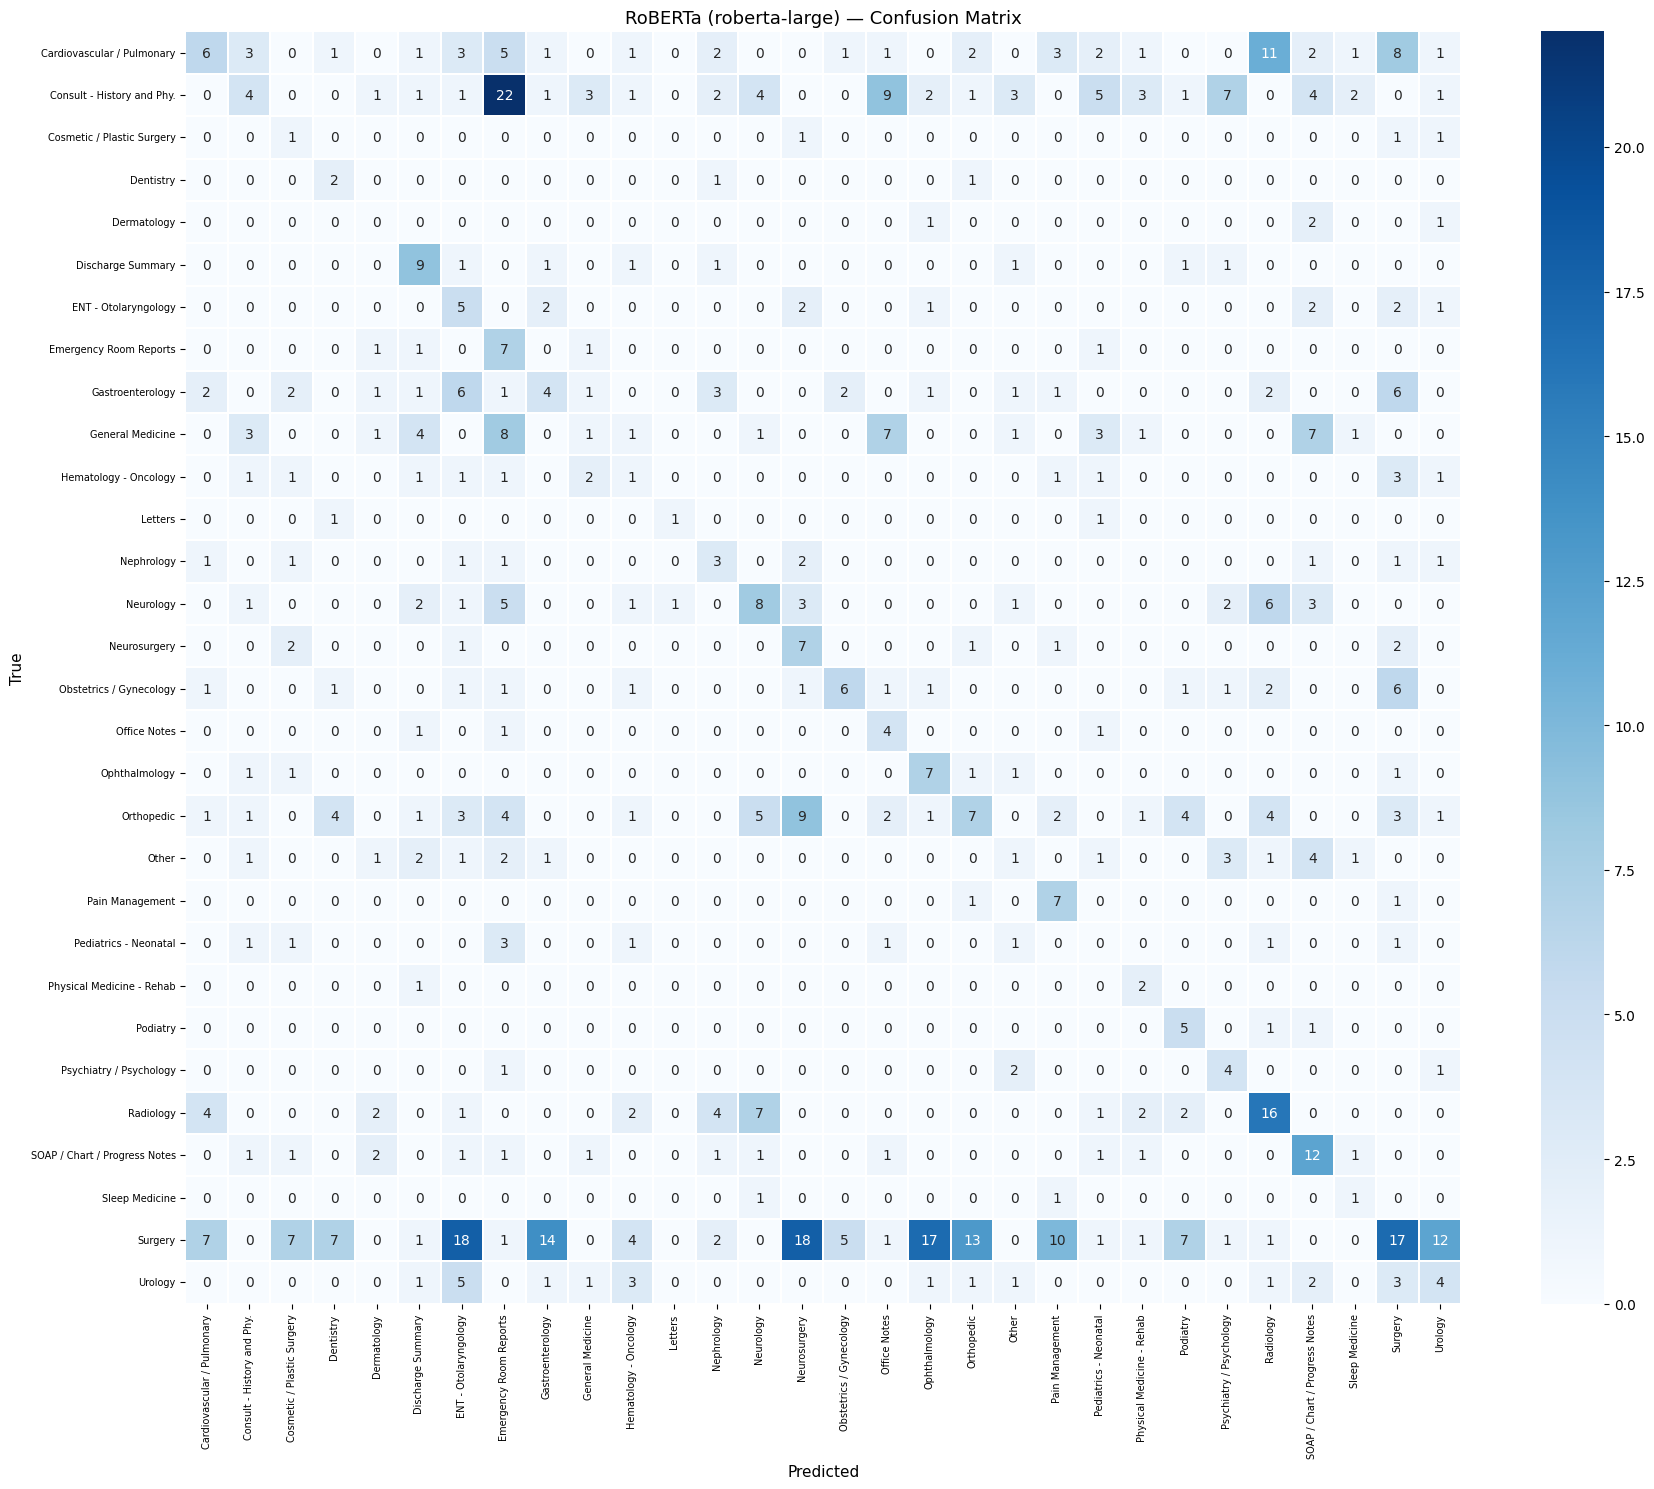

In [28]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.3)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)
plt.title(f"RoBERTa ({MODEL_NAME}) — Confusion Matrix", fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

## 9 · Save Model

Saves in HuggingFace format load it with:
    AutoModelForSequenceClassification.from_pretrained(path)

Also saves label_mappings.json — teammate MUST use the same
label2id so class indices align when combining predictions.

In [29]:
HF_SAVE_PATH = os.path.join(SAVE_DIR, "hf_model")
os.makedirs(HF_SAVE_PATH, exist_ok=True)

model.save_pretrained(HF_SAVE_PATH)
tokenizer.save_pretrained(HF_SAVE_PATH)

with open(os.path.join(HF_SAVE_PATH, "label_mappings.json"), "w") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, indent=2)

print(f"Model saved to: {HF_SAVE_PATH}")
print("\nFiles:")
for fname in sorted(os.listdir(HF_SAVE_PATH)):
    kb = os.path.getsize(os.path.join(HF_SAVE_PATH, fname)) // 1024
    print(f"  {fname:<40} {kb:>8} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/specality_classification/roberta_best/hf_model

Files:
  config.json                                     1 KB
  label_mappings.json                             1 KB
  model.safetensors                         1388291 KB
  tokenizer.json                               1174 KB
  tokenizer_config.json                        1074 KB


## 10 · Quick Inference Check

Loads the saved model fresh (simulates what demo.py will do) and runs
a prediction. Top-3 output with confidence scores.

In [30]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

inf_model = AutoModelForSequenceClassification.from_pretrained(HF_SAVE_PATH)
inf_tok   = AutoTokenizer.from_pretrained(HF_SAVE_PATH)
inf_model.to(device).eval()

with open(os.path.join(HF_SAVE_PATH, "label_mappings.json")) as f:
    mappings = json.load(f)
_id2label = mappings["id2label"]

def predict(text: str, top_k: int = 3):
    enc = inf_tok(
        clean(text), max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        probs = F.softmax(inf_model(**enc).logits, dim=-1)[0].cpu().numpy()

    top_idx = np.argsort(probs)[::-1][:top_k]
    print(f"{'Rank':<5} {'Specialty':<45} {'Confidence':>10}  Bar")
    print("-" * 75)
    for rank, idx in enumerate(top_idx, 1):
        bar = "█" * int(probs[idx] * 40)
        print(f"{rank:<5} {_id2label[str(idx)]:<45} {probs[idx]:>9.1%}  {bar}")

sample = """
SUBJECTIVE: 47-year-old male with acute low back pain after heavy lifting.
Radiating numbness down left leg to foot. Pain 7/10.
OBJECTIVE: L4-L5 tenderness. Positive straight-leg raise left at 45 degrees.
ASSESSMENT: Lumbar disc herniation, L5 radiculopathy.
PLAN: MRI lumbar spine, NSAIDs, physical therapy referral.
"""

predict(sample, top_k=3)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Rank  Specialty                                     Confidence  Bar
---------------------------------------------------------------------------
1     SOAP / Chart / Progress Notes                     13.7%  █████
2     Office Notes                                      13.6%  █████
3     Other                                             11.4%  ████
